# Georgian Spellchecker — Data Pipeline and Training

The following model is trained in Kaggle as my Google colab's GPU disconnected multiple times during training.

## Problem framing

Spellchecking is a sequence-to-sequence transformation: given a sequence of characters that may contain errors, produce the corrected sequence of characters. This is not a classification problem (where the output is a fixed label) and not a language model problem (where context across words matters). It is purely a character-level transduction task — the model must learn what valid Georgian orthography looks like and repair deviations from it.

We implement this with an encoder-decoder architecture. The encoder reads the corrupted word character by character and produces a fixed-dimensional summary of what it has read. The decoder then generates the corrected word one character at a time, consulting the encoder's output via an attention mechanism at each step. This structure handles variable input and output lengths naturally, which a single-sequence RNN cannot do when the output length differs from the input length.

## Why character-level

Georgian has a one-to-one correspondence between phonemes and letters, a property called phonemic orthography. There are 33 letters and no silent characters. This makes the character level the natural granularity: spelling errors are insertions, deletions, substitutions, or transpositions of individual characters, and the correction is always expressible as a character-level edit. Subword or word-level tokenisation would obscure exactly the signal the model needs to learn.

## Architecture summary

- Encoder: 2-layer bidirectional GRU. Reads the input in both directions so that every character's encoding has access to the full word context, not just what came before it.
- Attention: Bahdanau  attention. At each decoder step, computes a weighted sum over all encoder outputs, allowing the decoder to focus on the part of the input most relevant to what it is currently generating.
- Decoder: 2-layer unidirectional GRU. Generates one character per step, conditioned on the attention context and its own previous output.
- Training: Teacher forcing with scheduled decay, label smoothing, AdamW optimiser, ReduceLROnPlateau scheduler, early stopping.

## Cell 1 — Imports

Standard library and third-party imports. `sklearn` is used only for the train/validation split. All neural network components come from PyTorch. Seeds are fixed for reproducibility across runs.

In [1]:
import os, re, random, time
from pathlib import Path
from collections import Counter

import requests
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU. Training will be very slow.')

Device: cuda
GPU: Tesla T4


## Cell 2 — Load data files

Data is loaded from files uploaded to the session. The primary source is ganmarteba_words.txt, a word list extracted from the Ganmarteba.ge Georgian dictionary. This gives a clean, high-quality base vocabulary of correctly spelled Georgian words(I took this from a repository as ganmarteba.ge itself didn't have an api for me to extract directly). Additional data comes from wikipedia articles fetched firectly in the code, also uploaded literature files(იგი, ჯინსების თაობა) and Georgian constitution for more diverse/formal language (all of these i had to turn into txt because urls don't work proprrly).

In [ ]:
# On Kaggle: Add dataset via Data -> Add Data, update DATASET_DIR
# to the path shown in the Data panel (e.g. /kaggle/input/your-dataset-name).
# The loop below finds all .txt files under that directory and copies them
# to the working directory so later cells can open them by filename.
#(The notebook can be run on Colab as well just need to change this and last cells)

DATASET_DIR = Path('/kaggle/input/datasets/marss2006/georgian-spellchecker-data')

uploaded = {}
for p in DATASET_DIR.rglob('*.txt'):
    data = p.read_bytes()
    uploaded[p.name] = data
    Path(p.name).write_bytes(data)
    print(f'Found: {p.name}  ({len(data):,} bytes)')

if 'ganmarteba_words.txt' not in uploaded:
    print('WARNING: ganmarteba_words.txt not found. Vocabulary will be smaller.')

txt_extras = [f for f in uploaded if f.endswith('.txt') and f != 'ganmarteba_words.txt']
print(f'Dictionary: {"found" if "ganmarteba_words.txt" in uploaded else "missing"}')
print(f'Extra text files: {txt_extras}')

Found: konstitucia.txt  (266,511 bytes)
Found: ganmarteba_words.txt  (1,135,613 bytes)
Found: jinsebis taoba.txt  (2,278,773 bytes)
Found: igi.txt  (183,094 bytes)
Dictionary: found
Extra text files: ['konstitucia.txt', 'jinsebis taoba.txt', 'igi.txt']


## Cell 3 — Configuration

Global hyperparameters for data generation. These values control the character of the training set before any model code runs.

PAIRS_PER_WORD = 15: Each word in the vocabulary generates 15 training pairs. Because error application is stochastic, these 15 pairs will show different corruptions of the same word: different positions, different error types, sometimes one error and sometimes two. 

CLEAN_RATIO = 0.35: 35% of pairs are identity pairs where the input equals the target. This is necessary because a deployed spellchecker receives mostly correct words in practice. Without clean pairs, the model never learns the condition "this input needs no changes" and will hallucinate corrections on perfectly valid words. 

MIN_WORD_LEN = 3 / MAX_WORD_LEN = 2`: Very short words (1-2 characters) provide almost no learning signal and are also mostly prepositions or particles that appear differently in context. Very long words (>20 characters) are rare enough that they are not worth the padding overhead they impose on shorter sequences in the same batch.

In [3]:
PAIRS_PER_WORD = 15
CLEAN_RATIO    = 0.35
MIN_WORD_LEN   = 3
MAX_WORD_LEN   = 20
REQUEST_DELAY  = 2.0
MAX_RETRIES    = 3

# The full Georgian Mkhedruli alphabet used in modern writing.
# This string defines both the regex filter and the character vocabulary.
GEO         = 'აბგდევზთიკლმნოპჟრსტუფქღყშჩცძწჭხჯჰ'
GEO_PATTERN = re.compile(r'[' + GEO + ']{3,}')   # extract Georgian tokens from raw text
GEO_RE      = re.compile(r'^[' + GEO + ']+$')     # validate that a word is purely Georgian
HEADERS     = {'User-Agent': 'GeorgianSpellcheckerBot/1.0 (student NLP project)'}

# Wikipedia articles used for supplementary vocabulary.
# Topics chosen to cover a broad range of Georgian vocabulary:
# geography, science, culture, law, and everyday subjects.
WIKIPEDIA_TITLES = [
    'საქართველო', 'თბილისი', 'ქართული_ენა', 'ისტორია',
    'მეცნიერება', 'განათლება', 'კულტურა', 'ეკონომიკა',
    'პოლიტიკა', 'სამართალი', 'სპორტი', 'ხელოვნება',
    'გეოგრაფია', 'ბიოლოგია', 'ფიზიკა', 'მათემატიკა',
    'ლიტერატურა', 'მუსიკა', 'კინო', 'არქიტექტურა',
    'ფილოსოფია', 'ფსიქოლოგია', 'სოციოლოგია', 'ეკოლოგია',
    'ასტრონომია', 'ქიმია', 'მედიცინა', 'ტექნოლოგია',
]

def extract_words(text):
    """Extract all Georgian token sequences of length >= 3 from raw text."""
    return GEO_PATTERN.findall(text)

def fetch_with_retry(url):
    """HTTP GET with exponential backoff on rate limiting."""
    for attempt in range(MAX_RETRIES):
        try:
            r = requests.get(url, headers=HEADERS, timeout=20)
            if r.status_code == 429:
                time.sleep(REQUEST_DELAY * (attempt + 2))
                continue
            r.raise_for_status()
            return r
        except requests.exceptions.RequestException as e:
            print(f'  attempt {attempt+1} failed: {e}')
            time.sleep(REQUEST_DELAY)
    return None

def fetch_wikipedia(title):
    """Fetch the plain-text extract of a Georgian Wikipedia article."""
    url = (
        'https://ka.wikipedia.org/w/api.php'
        f'?action=query&titles={title}&prop=extracts'
        '&explaintext=true&format=json&redirects=1'
    )
    r = fetch_with_retry(url)
    if r is None:
        return ''
    pages = r.json().get('query', {}).get('pages', {})
    for page in pages.values():
        return page.get('extract', '')
    return ''

print('Configuration ready.')

Configuration ready.


## Cell 4 — Vocabulary collection

Words are gathered from three sources and pooled into a single list. Deduplication and quality filtering happen in the next cell.
The dictionary words are read one per line, which is the format of ganmarteba_words.txt. The Wikipedia fetch uses the MediaWiki API's 'extracts` property, which returns the article body as plain text without markup, this avoids having to parse wikitext. 

In [4]:
all_words = []

# --- Primary source: Ganmarteba dictionary ---
# Each line is one correctly spelled Georgian word.
# Lines starting with '#' are comments and are skipped.
if Path('ganmarteba_words.txt').exists():
    dict_words = []
    with open('ganmarteba_words.txt', 'r', encoding='utf-8') as f:
        for line in f:
            word = line.strip()
            if not word or word.startswith('#'):
                continue
            if GEO_RE.fullmatch(word) and MIN_WORD_LEN <= len(word) <= MAX_WORD_LEN:
                dict_words.append(word)
    all_words.extend(dict_words)
    print(f'Ganmarteba dictionary:  {len(dict_words):>7,} words  ({len(set(dict_words)):,} unique)')
else:
    print('ganmarteba_words.txt not found')

# --- Secondary source: uploaded text files ---
# GEO_PATTERN extracts all Georgian character sequences of length >= 3.
# These files may contain mixed-script content; the regex filters to Georgian only.
txt_extras = [f for f in uploaded if f.endswith('.txt') and f != 'ganmarteba_words.txt']
for filename in txt_extras:
    text  = Path(filename).read_text(encoding='utf-8')
    words = extract_words(text)
    all_words.extend(words)
    print(f'{filename:<40}  {len(words):>7,} words  ({len(set(words)):,} unique)')

# --- Tertiary source: Georgian Wikipedia ---
# 28 articles covering broad vocabulary. Plain-text extraction via API.
wiki_words = []
print(f'\nFetching {len(WIKIPEDIA_TITLES)} Wikipedia articles...')
for title in WIKIPEDIA_TITLES:
    text  = fetch_wikipedia(title)
    words = extract_words(text)
    wiki_words.extend(words)
    print(f'  {title:<30}  {len(words):>5,} words')
    time.sleep(REQUEST_DELAY)

all_words.extend(wiki_words)
print(f'\nWikipedia total:  {len(wiki_words):>7,} words')
print(f'Grand total raw:  {len(all_words):>7,} tokens')

Ganmarteba dictionary:   40,532 words  (40,532 unique)
konstitucia.txt                             9,084 words  (2,290 unique)
jinsebis taoba.txt                         99,960 words  (7,811 unique)
igi.txt                                     8,995 words  (2,677 unique)

Fetching 28 Wikipedia articles...
  საქართველო                      3,072 words
  თბილისი                         3,985 words
  ქართული_ენა                     2,143 words
  ისტორია                           617 words
  მეცნიერება                      1,123 words
  განათლება                         328 words
  კულტურა                         2,309 words
  ეკონომიკა                         376 words
  პოლიტიკა                          221 words
  სამართალი                         136 words
  სპორტი                              0 words
  ხელოვნება                           0 words
  გეოგრაფია                       3,195 words
  ბიოლოგია                          243 words
  ფიზიკა                          3,774 words
  მა

## Cell 5 — Vocabulary filtering

Four filters are applied in sequence to remove noise before training pairs are generated. Each filter removes a different category of problematic word.

Length filter: Removes words outside the 3-20 character range.

Script filter: Removes any word containing non-Georgian characters. The regex GEO_RE matches only the 33 Mkhedruli letters, anything with digits, latin characters or punctuation is dropped.

Rare character filter: A character that appears in fewer than 0.01% of all character occurrences across the corpus is considered rare enough to indicate a data quality problem (OCR artefact, encoding error, archaic letter). Words containing such characters are removed.

Bigram filter: Georgian phonotactics constrain which character pairs can appear adjacent to each other. A bigram that appears fewer than 3 times across the entire corpus is almost certainly not a valid Georgian character sequence. This filter removes words produced by noise or extraction errors that happen to consist entirely of Georgian characters but are not plausible Georgian words.

After filtering, the vocabulary is capped at 60,000 words prioritised by character frequency (more common characters = more likely to be frequent real words). This cap prevents memory issues on machines with limited RAM while keeping the most informative words.

In [5]:
step1 = [w for w in all_words if MIN_WORD_LEN <= len(w) <= MAX_WORD_LEN]
print(f'After length filter:       {len(step1):>8,}')

step2 = [w for w in step1 if GEO_RE.match(w)]
print(f'After script filter:       {len(step2):>8,}')

# Character frequency across the full corpus
char_freq = Counter(''.join(step2))
total_ch  = sum(char_freq.values())
common_ch = {c for c, n in char_freq.items() if n / total_ch >= 0.0001}
step3     = [w for w in step2 if all(c in common_ch for c in w)]
print(f'After rare-char filter:    {len(step3):>8,}')

# Bigram frequency — filters implausible character combinations
bg_freq = Counter()
for w in step3:
    for i in range(len(w) - 1):
        bg_freq[w[i:i+2]] += 1
step4 = [w for w in step3
         if all(bg_freq[w[i:i+2]] >= 3 for i in range(len(w) - 1))]
print(f'After bigram filter:       {len(step4):>8,}')

# Deduplicate and cap at 60,000, keeping the highest-frequency words
unique_words = list(set(step4))
if len(unique_words) > 60_000:
    def word_score(w): return sum(char_freq[c] for c in w) / len(w)
    unique_words = sorted(unique_words, key=word_score, reverse=True)[:60_000]
    print(f'After top-60K cap:         {len(unique_words):>8,}')

random.shuffle(unique_words)
print(f'\nFinal vocabulary: {len(unique_words):,} words')

After length filter:        187,670
After script filter:        187,670
After rare-char filter:     187,670
After bigram filter:        187,589

Final vocabulary: 57,082 words


## Cell 6 — Error generator

Training pairs are generated by applying synthetic errors to correct words. The quality of this error generation is the most important factor in whether the model learns to correct real misspellings/errors that do not resemble how humans actually mistype Georgian will train the model to correct a different distribution than what it encounters in practice.

### Keyboard adjacency map

The Georgian keyboard layout has a specific physical arrangement of keys. The most common typing error is pressing a key adjacent to the intended one. The adjacency map encodes this: for each Georgian character, we record which characters occupy neighbouring keys on the standard Georgian layout. 

### Error types

Eight error types are implemented, each modelling a distinct real-world georgian errors:

- substitute (25%): Replace a character with an adjacent key character. Models finger slip errors, replacing a character with neigbouring one.
- same key (20%): Replace a character with its same physical key counterpart.As on the Georgian keyboard, several characters share a key with other characters from alphabet confusions are very common.
- delete (15%): Remove a character entirely. Models a key press that did not register.
- final swap (8%): Swap the final consonant for a common alternative (თ/დ). This is a specific Georgian orthographic confusion that occurs frequently in handwriting and fast typing.
- insert (12%): Insert an extra adjacent-key character. Models an accidental double-press or finger landing on two keys.
- transpose (5%): Swap two adjacent characters. Models the common error of fingers arriving in the wrong order.
- double (8%): Duplicate a character. Models a key held too long or pressed twice.
- drop vowel (7%): Remove a vowel specifically. Georgian vowels are frequently omitted in fast informal typing.
### Multi-error scaling

Longer words receive more errors with higher probability. A 15-character word might realistically have two or three typos, a smaller word almost never has more than one. The error count probabilities are scaled by word length accordingly. 

### Clean pairs

With probability CLEAN_RATIO, a word is returned unchanged as both input and target. This is essential: at inference time, most words submitted to the spellchecker will already be correct. If the model only ever sees corrupted inputs during training, it learns that every input requires a change, and it will corrupt correct words. Clean pairs teach the identity transformation.

In [6]:
# Georgian keyboard layout — Mkhedruli characters in their standard row positions.
# This is the basis for realistic substitution errors (adjacent key presses).
GEO_KEYBOARD_ROWS = [
    'ქწერტყუიოპ',   # top row
    'ასდფგჰჯკლ',    # home row
    'ზხცვბნმ',      # bottom row
    'თღშჩძჭჟ',      # additional Georgian characters
]

def build_adjacency_map(rows):
    """For each character, find all characters in the 8 neighbouring grid positions."""
    pos = {ch: (r, c) for r, row in enumerate(rows) for c, ch in enumerate(row)}
    adj = {}
    for ch, (r, c) in pos.items():
        nbrs = []
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == dc == 0:
                    continue
                nr, nc = r + dr, c + dc
                if 0 <= nr < len(rows) and 0 <= nc < len(rows[nr]):
                    nbrs.append(rows[nr][nc])
        adj[ch] = nbrs
    return adj

ADJ       = build_adjacency_map(GEO_KEYBOARD_ROWS)
GEO_CHARS = list(''.join(GEO_KEYBOARD_ROWS))   # all characters with known keyboard positions

# Same-physical-key pairs: these characters share a key on the standard Georgian/Latin
# keyboard. Confusion between them is one of the most common Georgian typing errors.
SAME_KEY_PAIRS = {
    'წ': 'შ', 'შ': 'წ', 'ძ': 'ხ', 'ხ': 'ძ',
    'ტ': 'თ', 'თ': 'ტ', 'რ': 'ღ', 'ღ': 'რ',
    'ჩ': 'ც', 'ც': 'ჩ', 'ჭ': 'ჯ', 'ჯ': 'ჭ',
}

# Final-consonant confusion: თ and დ are frequently swapped at word endings
# in fast Georgian typing, particularly in verb conjugations.
FINAL_SWAP = {'თ': 'დ', 'დ': 'თ'}

# Georgian vowels — drop_vowel error targets these specifically
VOWELS = set('აეიოუ')

def apply_single_error(corrupted):
    """Apply one error to the character list in place and return it.

    The error type is sampled according to weights that reflect the empirical
    frequency of each error type in Georgian typing. Deletion and insertion
    are guarded by a minimum length check to prevent producing empty or
    single-character words.
    """
    if len(corrupted) < 2:
        return corrupted
    op = random.choices(
        ['substitute', 'same_key', 'delete', 'final_swap', 'insert',
         'transpose',  'double',   'drop_vowel'],
        weights=[0.25,   0.20,      0.15,    0.08,         0.12,
                 0.05,   0.08,      0.07]
    )[0]
    idx = random.randrange(len(corrupted))

    if op == 'substitute':
        # Replace with an adjacent-key character; fall back to any Georgian char
        # if the character is not in the keyboard map (e.g. rare letters)
        cands = ADJ.get(corrupted[idx], GEO_CHARS)
        corrupted[idx] = random.choice(cands) if cands else random.choice(GEO_CHARS)
    elif op == 'same_key':
        # Find all positions in the word where a same-key swap is possible
        cands = [i for i, c in enumerate(corrupted) if c in SAME_KEY_PAIRS]
        if cands:
            i = random.choice(cands)
            corrupted[i] = SAME_KEY_PAIRS[corrupted[i]]
        else:
            # No same-key characters in this word; fall back to random substitution
            corrupted[idx] = random.choice(GEO_CHARS)
    elif op == 'delete' and len(corrupted) > MIN_WORD_LEN:
        corrupted.pop(idx)
    elif op == 'final_swap':
        if corrupted[-1] in FINAL_SWAP:
            corrupted[-1] = FINAL_SWAP[corrupted[-1]]
    elif op == 'insert':
        ins = random.choice(ADJ.get(corrupted[idx], GEO_CHARS))
        corrupted.insert(idx, ins)
    elif op == 'transpose' and idx < len(corrupted) - 1:
        corrupted[idx], corrupted[idx+1] = corrupted[idx+1], corrupted[idx]
    elif op == 'double':
        # Insert a copy of the character immediately after it
        corrupted.insert(idx, corrupted[idx])
    elif op == 'drop_vowel':
        vpos = [i for i, c in enumerate(corrupted) if c in VOWELS]
        if vpos and len(corrupted) > MIN_WORD_LEN:
            corrupted.pop(random.choice(vpos))
    return corrupted

def corrupt_word(word, p_clean=CLEAN_RATIO):
    """Return a (corrupted, original) training pair.

    With probability p_clean, the word is returned unchanged as both input
    and target. This teaches the model the identity transformation for
    already-correct inputs.

    The number of errors applied scales with word length: very short words
    get one error; longer words can get two or three. This reflects how
    absolute error count scales with word length in real typing.
    """
    if random.random() < p_clean or len(word) < 2:
        return word, word
    if len(word) > 12:
        n_errors = random.choices([1, 2, 3], weights=[0.40, 0.45, 0.15])[0]
    elif len(word) > 6:
        n_errors = random.choices([1, 2], weights=[0.55, 0.45])[0]
    else:
        n_errors = 1
    corrupted = list(word)
    for _ in range(n_errors):
        corrupted = apply_single_error(corrupted)
        if len(corrupted) < 2:
            break
    return ''.join(corrupted), word

print('Error types: substitute, same_key, delete, final_swap, insert, transpose, double, drop_vowel')
print()
print(f'  {"original":<22}  sample corruptions')
print('  ' + '-'*55)
for w in ['საქართველო', 'კონსტიტუცია', 'პარლამენტი', 'დამოუკიდებლობა', 'სახელმწიფო']:
    variants = [corrupt_word(w)[0] for _ in range(4)]
    print(f'  {w:<22}  {" | ".join(variants)}')

Error types: substitute, same_key, delete, final_swap, insert, transpose, double, drop_vowel

  original                sample corruptions
  -------------------------------------------------------
  საქართველო              სააართველო | საქართვეკო | საქართველო | სქართველო
  კონსტიტუცია             კონსტიტუციია | კონსტიკტუცია | კონსტიტუცია | კონსტიტუცია
  პარლამენტი              პარლამენჰი | პარლამენტი | პარლამენტი | პარლამენტოი
  დამოუკიდებლობა          ხამოუკიეებობა | დამოუკილებლობა | დამოუკლდებლკბა | დამზოუკიდებლბა
  სახელმწიფო              სახელმწიფო | სახელმშიფ | სახელმწიფო | საეოლმწიფო


## Cell 7 — Train and validation split

The vocabulary is split into train and validation word sets before any pairs are generated. This is the correct way to prevent data leakage: if a word appears in the training vocabulary, none of its corrupted variants appear in the validation set. The model is therefore evaluated on words it has never seen in any form during training.

A separate list val_corrupted is constructed from validation pairs where the input differs from the target. This is used to measure the true correction rate, the fraction of actually-wrong words the model fixes correctly(to get better picture). A model that simply copies its input would score 100% on the full val_pairs if all examples were clean, but 0% on val_corrupted. 

In [7]:
# Split words before generating pairs to prevent data leakage
train_words, val_words = train_test_split(unique_words, test_size=0.10, random_state=SEED)

def make_pairs(words, n=PAIRS_PER_WORD):
    """Generate n training pairs per word by repeated stochastic corruption."""
    pairs = []
    for w in words:
        if MIN_WORD_LEN <= len(w) <= MAX_WORD_LEN:
            for _ in range(n):
                pairs.append(corrupt_word(w))
    random.shuffle(pairs)
    return pairs

train_pairs = make_pairs(train_words)
val_pairs   = make_pairs(val_words)

# Corrupted-only subset for honest correction rate measurement
val_corrupted = [(s, t) for s, t in val_pairs if s != t]

for name, pairs in [('Train', train_pairs), ('Val', val_pairs)]:
    n_clean = sum(1 for c, o in pairs if c == o)
    print(f'{name}: {len(pairs):>8,} pairs  (clean {n_clean:,} / corrupted {len(pairs)-n_clean:,})')

print(f'Val corrupted only: {len(val_corrupted):,}  (used for correction rate metric)')
print()
print('Sample corrupted -> correct:')
for c, o in random.sample([p for p in train_pairs if p[0] != p[1]], 8):
    print(f'  {c:<25}  ->  {o}')

Train:  770,595 pairs  (clean 304,206 / corrupted 466,389)
Val:   85,635 pairs  (clean 33,819 / corrupted 51,816)
Val corrupted only: 51,816  (used for correction rate metric)

Sample corrupted -> correct:
  ნანრემსარი                 ->  ნანემსარი
  იპა                        ->  სპა
  ექყს                       ->  ექვს
  ჩასაღვასთან                ->  ჩასახვასთან
  წელკაცვი                   ->  წელკავი
  დააშყებინებს               ->  დააწყებინებს
  გამოწვრთჰა                 ->  გამოწვრთნა
  მოაბოწებს                  ->  მოაბოშებს


## Cell 8 — Character vocabulary and special tokens

The model operates on integer token IDs, not raw characters. We define a mapping from characters to integers and back.

special tokens are reserved at indices 0-3:

- PAD (0): Padding token. Shorter words in a batch are padded to the same length with other words with this token. The loss function ignores PAD positions, so padding does not contribute to the gradient.
- SOS (1): Start-of-sequence token. The decoder receives this as its first input token at every step, signalling the beginning of the output sequence. Without SOS, the decoder has no input for its first generation step.
- EOS (2): End-of-sequence token. The target sequence ends with EOS, training the decoder to emit this token when the output is complete. At inference, generation stops when EOS is produced. This allows the output length to vary freely and the model decides when it is done.
- UNK (3): Unknown token. Any character not in the vocabulary maps to UNK. In practice this should never occur because our vocabulary covers the full Georgian alphabet, but it provides a safe fallback.

The vocabulary is built from the full 33-character Georgian Mkhedruli alphabet, this guarantees that every possible Georgian character is representable, even if it rarely appeared in the training data. 

In [8]:
PAD, SOS, EOS, UNK = 0, 1, 2, 3
SPECIAL      = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

# Full Mkhedruli alphabet — all 33 modern Georgian letters.
# Built from the explicit alphabet string rather than corpus frequency
# so that rare but valid characters are always representable.
GEO_ALPHABET = list('აბგდევზთიკლმნოპჟრსტუფქღყშჩცძწჭხჯჰ')
all_chars    = SPECIAL + GEO_ALPHABET
char2idx     = {ch: i for i, ch in enumerate(all_chars)}
idx2char     = {v: k for k, v in char2idx.items()}
VOCAB_SIZE   = len(char2idx)

print(f'Vocabulary: {VOCAB_SIZE} tokens')
print(f'  Special tokens: {SPECIAL}')
print(f'  Georgian characters: {len(GEO_ALPHABET)}')
print(f'  Total: {len(SPECIAL)} + {len(GEO_ALPHABET)} = {VOCAB_SIZE}')

Vocabulary: 37 tokens
  Special tokens: ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
  Georgian characters: 33
  Total: 4 + 33 = 37


## Cell 9 — Dataset and DataLoader

encode converts a word string into a list of integer token IDs. The optional add_eos flag appends the EOS token to mark the end of a target sequence. The source (corrupted) word is encoded without EOS, the target (correct) word is encoded with EOS and prepended with SOS to form the decoder's input/output pair.

decode_ids converts a list of token IDs back to a string, stopping at EOS and skipping all special tokens. This is used during evaluation to read the model's output.

collate_fn handles variable-length sequences in a batch. pad_sequence pads all sequences in the batch to the length of the longest one, using PAD (0) as the fill value.pack_padded_sequence in the encoder then tells PyTorch to skip the padded positions during the GRU forward pass, saving computation and preventing padding from influencing the hidden state.

Batch size 256 is chosen to make efficient use of GPU memory while keeping gradient estimates stable. num_workers=2 prefetches batches on CPU while the GPU processes the previous one.

In [9]:
def encode(word, add_eos=False):
    """Convert a word string to a list of token IDs.
    Unknown characters map to UNK (3). EOS is appended if add_eos=True.
    """
    ids = [char2idx.get(ch, UNK) for ch in word]
    if add_eos:
        ids.append(EOS)
    return ids

def decode_ids(ids):
    """Convert a list of token IDs back to a word string.
    Stops at EOS; skips PAD, SOS, and UNK.
    """
    out = []
    for i in ids:
        if i == EOS:
            break
        if i not in (PAD, SOS, UNK):
            out.append(idx2char.get(i, '?'))
    return ''.join(out)

class SpellDataset(Dataset):
    """Wraps a list of (corrupted, correct) string pairs as a PyTorch dataset.

    Each item is returned as two tensors:
      src: encoded corrupted word (no special tokens)
      tgt: [SOS] + encoded correct word + [EOS]
    The tgt sequence serves as both the decoder input (positions 0..T-1)
    and the decoder target (positions 1..T) during training.
    """
    def __init__(self, pairs): self.pairs = pairs
    def __len__(self):         return len(self.pairs)
    def __getitem__(self, idx):
        src_w, tgt_w = self.pairs[idx]
        return (torch.tensor(encode(src_w),             dtype=torch.long),
                torch.tensor([SOS]+encode(tgt_w, True), dtype=torch.long))

def collate_fn(batch):
    """Pad variable-length sequences in a batch to equal length.

    Returns padded src and tgt tensors of shape (B, T_max) and
    length tensors used by pack_padded_sequence in the encoder.
    """
    srcs, tgts = zip(*batch)
    src_lens   = torch.tensor([len(s) for s in srcs])
    tgt_lens   = torch.tensor([len(t) for t in tgts])
    return (pad_sequence(srcs, batch_first=True, padding_value=PAD),
            pad_sequence(tgts, batch_first=True, padding_value=PAD),
            src_lens, tgt_lens)

BATCH_SIZE   = 256
train_loader = DataLoader(SpellDataset(train_pairs), batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(SpellDataset(val_pairs),   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val   batches: {len(val_loader)}')

Train batches: 3011
Val   batches: 335


## Cell 10 — Model architecture

### Encoder

The encoder is a 2-layer bidirectional GRU. Each character embedding is fed through the GRU in both left-to-right and right-to-left directions. The output at each position is the concatenation of both directional hidden states, giving it access to the full word context. This is important for spellchecking, deciding what to output at position *t* in the correction may depend on characters that appear after position *t* in the input.

The encoder reads the full input sequence and compresses it into a hidden state. The decoder then generates output characters one at a time, stopping when it produces an EOS token. Because the decoder decides when to stop independently of the input length, the output can be shorter (after deleting an extra character) or longer (after inserting a missing one) than the input.

The encoder's final hidden state is the concatenation of the last forward and last backward hidden states, projected down to HIDDEN_DIM via a linear layer followed by tanh. This projection is necessary because the encoder is bidirectional (output dimension 2 * HIDDEN_DIM) but the decoder expects HIDDEN_DIM. The tanh keeps the initial decoder hidden state in a reasonable range.

pack_padded_sequence and pad_packed_sequence are used to skip padding positions during the GRU computation, preventing PAD tokens from polluting the hidden state representations.


### Attention

Bahdanau attention computes a score for each encoder output position at each decoder step. The score is computed by concatenating the decoder's current hidden state with each encoder output, passing through a linear layer and tanh, then projecting to a scalar. Softmax over these scalars gives attention weights. Positions corresponding to PAD tokens in the source are masked to -inf before softmax, ensuring the decoder never attends to padding.The mask is computed once in Seq2Seq.forwar as src != PAD and passed explicitly to the decoder at every step. This is important, the mask must be the same object (based on the original padded source) at both training time (batched, padded) and inference time (single word, no padding). If the decoder recomputed its own mask from enc_out, the mask would differ between training and inference, creating a mismatch that causes copying behaviour.

### Decoder

The decoder is a 2-layer unidirectional GRU. At each step it receives the embedding of the previous output character and the attention context vector (weighted sum of encoder outputs). These are concatenated and fed into the GRU. The GRU output is concatenated with the context vector again and passed through a linear layer to produce logits over the vocabulary.

Concatenating the context vector at both input and output of the GRU (rather than only at input) gives the decoder direct access to the attended encoder information when computing the output logits, which empirically improves performance on short sequences.

### Design choices

HIDDEN_DIM = 512: Sufficient capacity for character-level patterns over sequences of at most 20 characters. The task does not require larger representations.

DROPOUT = 0.35: Applied to embeddings and GRU inputs. Regularises the model against memorising specific corruption patterns in the training set. 

N_LAYERS = 2: Two GRU layers in both encoder and decoder. A single layer underfit on this vocabulary size, three layers showed no improvement and slowed training.

In [ ]:
class Attention(nn.Module):
    """Bahdanau (additive) attention.

    Computes a distribution over encoder output positions at each decoder step.
    The decoder's current hidden state is concatenated with each encoder output,
    projected to a scalar score, and normalised with softmax.
    PAD positions in the source are masked to -inf before softmax.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 3, hidden_dim)
        self.v    = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_out, mask):
        T      = enc_out.shape[1]
        dec_h  = dec_hidden.unsqueeze(1).repeat(1, T, 1)
        energy = torch.tanh(self.attn(torch.cat([dec_h, enc_out], dim=-1)))
        scores = self.v(energy).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e9)
        return torch.softmax(scores, dim=-1)


class Encoder(nn.Module):
    """Bidirectional 2-layer GRU encoder.

    Returns enc_out, hidden, and the PAD mask computed from src.
    The mask is returned here so that each DataParallel replica computes
    its own mask from its own src shard, preventing the size mismatch
    error that occurs when running on multiple GPUs.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(embed_dim, hidden_dim, n_layers, batch_first=True,bidirectional=True,dropout=dropout if n_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.dropout(self.embedding(src))
        src_lens = (src != PAD).sum(dim=1).cpu().clamp(min=1)
        packed = pack_padded_sequence(emb, src_lens, batch_first=True,enforce_sorted=False)
        out, hidden = self.gru(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        n = hidden.shape[0] // 2
        hidden = hidden.view(n, 2, hidden.shape[1], -1)
        hidden = torch.tanh(self.fc(torch.cat([hidden[:, 0], hidden[:, 1]], dim=-1)))
        mask = (src[:, :out.shape[1]] != PAD)
        return out, hidden, mask


class Decoder(nn.Module):
    """2-layer unidirectional GRU decoder with attention.
    Receives the mask from the encoder via Seq2Seq, does not recompute it.
    Recomputing from enc_out would give a different mask at inference
    (no padding) vs training (padded batches), causing copy-mode behaviour.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.attention = Attention(hidden_dim)
        self.gru       = nn.GRU(embed_dim + hidden_dim * 2, hidden_dim, n_layers,batch_first=True,dropout=dropout if n_layers > 1 else 0.0)
        self.fc_out    = nn.Linear(hidden_dim + hidden_dim * 2, vocab_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, token, hidden, enc_out, mask):
        emb     = self.dropout(self.embedding(token.unsqueeze(1)))
        attn_w  = self.attention(hidden[-1], enc_out, mask)
        context = torch.bmm(attn_w.unsqueeze(1), enc_out)
        gru_in  = torch.cat([emb, context], dim=-1)
        out, hidden = self.gru(gru_in, hidden)
        logits  = self.fc_out(torch.cat([out.squeeze(1), context.squeeze(1)], dim=-1))
        return logits, hidden


class Seq2Seq(nn.Module):
    """Encoder-decoder wrapper with teacher forcing.

    The mask is returned by the encoder and passed to every decoder step.
    This ensures each DataParallel replica uses the mask from its own src shard.
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, tgt, src_lens=None, tf_ratio=0.5):
        B, T_tgt              = tgt.shape
        enc_out, hidden, mask = self.encoder(src)   # mask comes from encoder
        dec_input             = tgt[:, 0]
        all_logits            = []
        for t in range(1, T_tgt):
            logits, hidden = self.decoder(dec_input, hidden, enc_out, mask)
            all_logits.append(logits.unsqueeze(1))
            dec_input = tgt[:, t] if random.random() < tf_ratio else logits.argmax(-1)
        return torch.cat(all_logits, dim=1)


EMBED_DIM  = 128    # character embedding dimension
HIDDEN_DIM = 512    # GRU hidden state dimension
N_LAYERS   = 2      # GRU layers in both encoder and decoder
DROPOUT    = 0.35   # dropout rate applied to embeddings and GRU inputs

enc   = Encoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
dec   = Decoder(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model = Seq2Seq(enc, dec, DEVICE)

if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs')
    model = nn.DataParallel(model)

model = model.to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print('Encoder returns mask — each DataParallel replica gets its own mask from its own src shard.')


Using 2 GPUs
Trainable parameters: 12,210,469
Encoder returns mask — each DataParallel replica gets its own mask from its own src shard.


## Cell 11 — Decode helpers

greedy_decode runs the model at inference time on a single word, producing the most likely output character at each step (argmax). It is fast and used for per-epoch accuracy tracking during training.

word_accuracy measures the correction rate on corrupted-only validation pairs. This is the honest metric: it asks what part of corrupted words are fixed correctly. A model that copies its input would score 0% here.




In [11]:
def greedy_decode(word, model_ref, c2i, i2c, max_len=40):
    """Decode a single word greedily (argmax at each step).

    Runs the encoder once, then steps through the decoder one token at a time,
    always feeding the previous argmax prediction as the next input.
    Stops at EOS or max_len characters.
    """
    model_ref.eval()
    mdl = model_ref.module if isinstance(model_ref, nn.DataParallel) else model_ref
    with torch.no_grad():
        ids     = [c2i.get(ch, UNK) for ch in word]
        src     = torch.tensor([ids], dtype=torch.long).to(DEVICE)
        enc_out, hidden, mask = mdl.encoder(src)   # unpack three values
        token   = torch.tensor([SOS], dtype=torch.long).to(DEVICE)
        result  = []
        for _ in range(max_len):
            logits, hidden = mdl.decoder(token, hidden, enc_out, mask)
            pred = logits.argmax(-1).item()
            if pred == EOS:
                break
            ch = i2c.get(pred, '')
            if ch not in ('<PAD>', '<SOS>', '<EOS>', '<UNK>'):
                result.append(ch)
            token = torch.tensor([pred], dtype=torch.long).to(DEVICE)
    return ''.join(result)


def word_accuracy(pairs, model_ref, c2i, i2c, n_samples=800):
    """Correction rate on corrupted-only pairs.

    Filters to pairs where input != target, then samples n_samples of them.
    Returns the fraction where greedy_decode produces the exact correct word.
    """
    corrupted_only = [(s, t) for s, t in pairs if s != t]
    sample  = random.sample(corrupted_only, min(n_samples, len(corrupted_only)))
    correct = sum(greedy_decode(s, model_ref, c2i, i2c) == t for s, t in sample)
    return correct / len(sample)


print('Decode helpers ready.')
print('word_accuracy() measures on corrupted pairs only — the true correction rate.')


Decode helpers ready.
word_accuracy() measures on corrupted pairs only — the true correction rate.


## Cell 12 — Training loop

### Loss function

CrossEntropyLoss with ignore_index=PAD computes the average cross-entropy over all non-padding output positions. label_smoothing=0.10 distributes 10% of the probability mass uniformly over all vocabulary entries instead of placing 100% on the correct token. This prevents the model from becoming overconfident on frequently-seen patterns and improves generalisation to rare corruptions.

### Optimiser and scheduler

AdamW with learning rate 1e-3 and weight decay 1e-4. Weight decay provides L2 regularisation on the weights. ReduceLROnPlateau halves the learning rate when validation loss has not improved for 5 epochs, allowing the model to continue improving at a smaller step size rather than diverging.

### Teacher forcing decay

Teacher forcing feeds the ground-truth previous token to the decoder during training rather than the model's own prediction. It stabilises early training (the model gets correct context even when its predictions are random) but creates a train/inference mismatch, at inference, the decoder always receives its own previous output. If teacher forcing stays high throughout training, the model never practices chaining its own predictions and performs poorly at inference.
Teacher forcing ratio decays linearly from 0.90 to a floor of 0.30 over 60 epochs. By the final epochs the model is generating 70% of each output sequence from its own predictions, which closely approximates inference conditions.

### Checkpointing and early stopping

The model checkpoint is saved to disk whenever validation loss improves. The checkpoint includes the model weights, architecture hyperparameters, and the character vocabulary, everything needed to reconstruct and run the model from a different notebook without access to the training code. Early stopping terminates training if validation loss has not improved for 15 epochs, preventing overfitting on the training pairs.

### Gradient clipping

clip_grad_norm_(max_norm=1.0) caps the global gradient norm before each parameter update. This prevents gradient explosions, which can occur in RNNs when long sequences cause gradients to grow exponentially through time.

In [ ]:
MODEL_PATH = 'georgian_spellchecker.pt'

criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.10)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-5
)

def run_epoch(loader, train=True, tf_ratio=0.5):
    """Run one full pass over the data loader.

    In train mode: computes gradients and updates parameters.
    In eval mode: computes loss only, tf_ratio is set to 0 (free-running).
    Returns mean loss over all batches.
    """
    model.train() if train else model.eval()
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt, src_lens, _ in loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)
            # logits shape: (B, T_tgt-1, V) — predictions for positions 1..T
            logits = model(src, tgt, src_lens, tf_ratio=tf_ratio if train else 0.0)
            B, T, V = logits.shape
            # Target is tgt[:,1:] — the decoder output positions (excluding SOS)
            loss = criterion(logits.reshape(B*T, V), tgt[:, 1:].reshape(B*T))
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

N_EPOCHS = 60
PATIENCE = 15
TF_START = 0.90
TF_FLOOR = 0.30

train_losses, val_losses, val_accuracies = [], [], []
best_val_loss = float('inf')
patience_ctr  = 0

print(f'Training for up to {N_EPOCHS} epochs  (patience={PATIENCE})')
print(f'Teacher forcing: {TF_START} -> {TF_FLOOR} (linear decay over {N_EPOCHS} epochs)')
print(f'Accuracy metric: corrupted val pairs only')
print()
print(f'{"Epoch":<7} {"TF":<6} {"Train Loss":<13} {"Val Loss":<13} {"Correction %":<14} {"LR":<11} Note')
print('-' * 75)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    # Linear decay: TF_START at epoch 1, TF_FLOOR at epoch N_EPOCHS
    tf = max(TF_FLOOR, TF_START - (TF_START - TF_FLOOR) * (epoch - 1) / (N_EPOCHS - 1))

    tr_loss = run_epoch(train_loader, train=True,  tf_ratio=tf)
    vl_loss = run_epoch(val_loader,   train=False)
    vl_acc  = word_accuracy(val_corrupted, model, char2idx, idx2char, n_samples=800)

    scheduler.step(vl_loss)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    val_accuracies.append(vl_acc)

    lr      = optimizer.param_groups[0]['lr']
    is_best = vl_loss < best_val_loss

    if is_best:
        best_val_loss = vl_loss
        patience_ctr  = 0
        # Save full checkpoint: weights + architecture hyperparameters + vocabulary.
        # Including hyperparameters and vocabulary means the inference notebook
        # can reconstruct the model without access to this training notebook.
        torch.save({
            'epoch':       epoch,
            'model_state': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
            'val_loss':    best_val_loss,
            'val_acc':     vl_acc,
            'char2idx':    char2idx,
            'idx2char':    idx2char,
            'vocab_size':  VOCAB_SIZE,
            'embed_dim':   EMBED_DIM,
            'hidden_dim':  HIDDEN_DIM,
            'n_layers':    N_LAYERS,
            'dropout':     DROPOUT,
        }, MODEL_PATH)
        note = 'best'
    else:
        patience_ctr += 1
        note = f'patience {patience_ctr}/{PATIENCE}'

    elapsed = time.time() - t0
    print(f'{epoch:<7} {tf:<6.2f} {tr_loss:<13.4f} {vl_loss:<13.4f} '
          f'{vl_acc*100:<13.1f}% {lr:<11.6f} {note}  [{elapsed:.0f}s]')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nBest val loss:        {best_val_loss:.4f}') #loss is only of corrupted pairs but computed on full val set with teacher forcing
print(f'Best correction rate: {max(val_accuracies)*100:.1f}%')
print(f'Model saved to: {MODEL_PATH}')

Training for up to 60 epochs  (patience=15)
Teacher forcing: 0.9 -> 0.3 (linear decay over 60 epochs)
Accuracy metric: corrupted val pairs only

Epoch   TF     Train Loss    Val Loss      Correction %   LR          Note
---------------------------------------------------------------------------
1       0.90   0.9335        1.2896        35.2         % 0.001000    best  [415s]
2       0.89   0.8609        1.2678        45.9         % 0.001000    best  [416s]
3       0.88   0.8517        1.2578        42.6         % 0.001000    best  [415s]
4       0.87   0.8504        1.2616        42.8         % 0.001000    patience 1/15  [415s]
5       0.86   0.8533        1.2625        43.4         % 0.001000    patience 2/15  [413s]
6       0.85   0.8579        1.2546        39.5         % 0.001000    best  [414s]
7       0.84   0.8636        1.2829        42.4         % 0.001000    patience 1/15  [413s]
8       0.83   0.8725        1.2721        39.4         % 0.001000    patience 2/15  [413s]
9   

## Cell 13 — Training curves

Two plots are shown side by side. The loss curves show whether the model is learning and whether it is overfitting (train loss falling while val loss rises). The correction rate curve shows the metric that actually matters for the task — what fraction of genuinely misspelled words the model corrects exactly. These two plots can diverge: a model with lower validation loss is not necessarily better at correcting words if the loss improvement comes from better confidence calibration on clean pairs rather than from learning harder corrections.

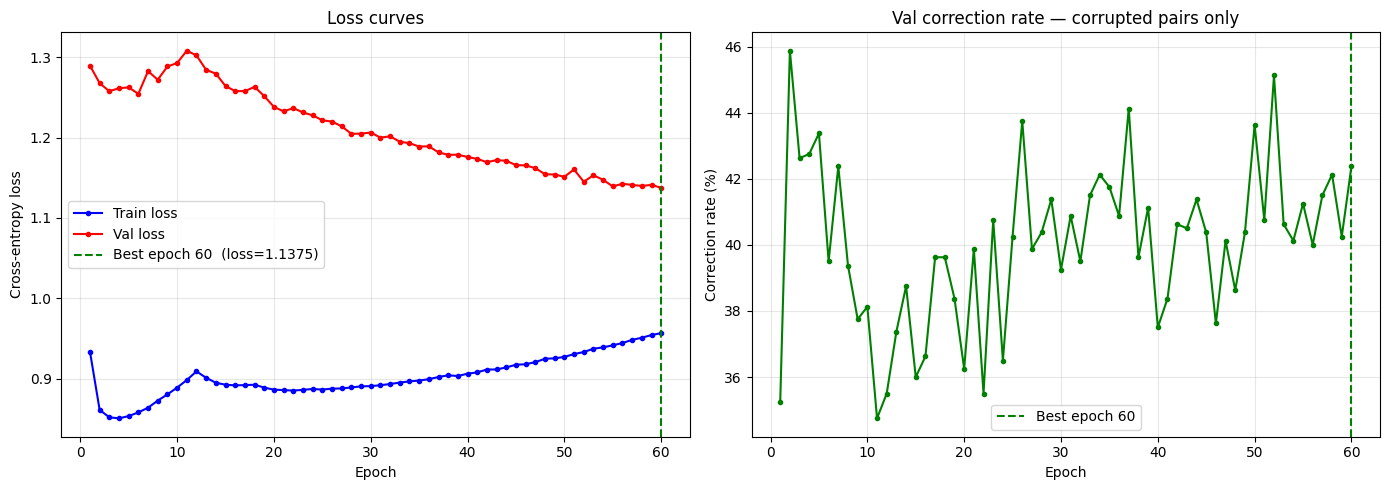

Peak correction rate: 45.9%  (epoch 2)


In [ ]:
best_epoch = val_losses.index(min(val_losses)) + 1
epochs     = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, 'b-o', markersize=3, label='Train loss')
ax1.plot(epochs, val_losses,   'r-o', markersize=3, label='Val loss')
ax1.axvline(x=best_epoch, color='green', linestyle='--',label=f'Best epoch {best_epoch}  (loss={best_val_loss:.4f})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Loss curves'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a*100 for a in val_accuracies], 'g-o', markersize=3)
ax2.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best epoch {best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Correction rate (%)')
ax2.set_title('Val correction rate — corrupted pairs only')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
CURVE_PATH = 'training_curves.png'
plt.savefig(CURVE_PATH, dpi=150)
plt.show()

best_acc = max(val_accuracies)
print(f'Peak correction rate: {best_acc*100:.1f}%  (epoch {val_accuracies.index(best_acc)+1})')

## Cell 14 — Export

The model is saved to georgian_spellchecker.pt during training. This cell confirms the file exists and prints its path. (Once again this is on kaggle due colab issuesm, but works perfectly in colab by applying minor change)

In [14]:
# Confirm model file exists on disk
model_file = Path(MODEL_PATH)
assert model_file.exists(), f'Model file not found: {MODEL_PATH}'
print(f'Model saved to:  {model_file.resolve()}')
print(f'File size:       {model_file.stat().st_size / 1e6:.1f} MB')
print(f'Curves saved to: {CURVE_PATH}')
print()
print('To use in inference.ipynb:')
print('  1. Publish this notebook output as a Kaggle dataset.')
print('  2. Add that dataset to inference.ipynb via Data -> Add Data.')
print('  3. Pass the model path to correct_word().')

Model saved to:  /kaggle/working/georgian_spellchecker.pt
File size:       48.9 MB
Curves saved to: training_curves.png

To use in inference.ipynb:
  1. Publish this notebook output as a Kaggle dataset.
  2. Add that dataset to inference.ipynb via Data -> Add Data.
  3. Pass the model path to correct_word().
